# Barrierefreie Farbwahl in der Datenvisualisierung

## Für den HsH Data Visualization Kurs

### Warum ist das wichtig?
- ~8% der Männer und ~0.5% der Frauen haben Farbenblindheit
- WCAG 2.1 Standards sind oft gesetzlich vorgeschrieben
- Gute Barrierefreiheit hilft allen Nutzern

### Lernziele
1. WCAG Kontrast-Standards verstehen (AA/AAA)
2. Farbenblindheit berücksichtigen
3. Barrierefreie Farbpaletten verwenden
4. Farben testen und validieren

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import to_rgb

%matplotlib inline
np.random.seed(42)

def relative_luminance(rgb):
    """Berechne relative Luminanz nach WCAG 2.1"""
    r, g, b = rgb
    def adjust(c):
        return c/12.92 if c <= 0.03928 else ((c + 0.055)/1.055)**2.4
    return 0.2126*adjust(r) + 0.7152*adjust(g) + 0.0722*adjust(b)

def contrast_ratio(c1, c2):
    """Berechne Kontrastverhältnis zwischen zwei Farben"""
    if isinstance(c1, str): c1 = to_rgb(c1)
    if isinstance(c2, str): c2 = to_rgb(c2)
    l1, l2 = relative_luminance(c1), relative_luminance(c2)
    return (max(l1,l2) + 0.05) / (min(l1,l2) + 0.05)

print("✓ Setup abgeschlossen")

✓ Setup abgeschlossen


## 1. WCAG Kontrast-Standards

**Mindestanforderungen:**
- **AA (Minimum)**: 4.5:1 für normalen Text, 3:1 für großen Text/Grafiken
- **AAA (Erweitert)**: 7:1 für normalen Text, 4.5:1 für großen Text

**Skala:** 1:1 (kein Kontrast) bis 21:1 (Schwarz/Weiß)

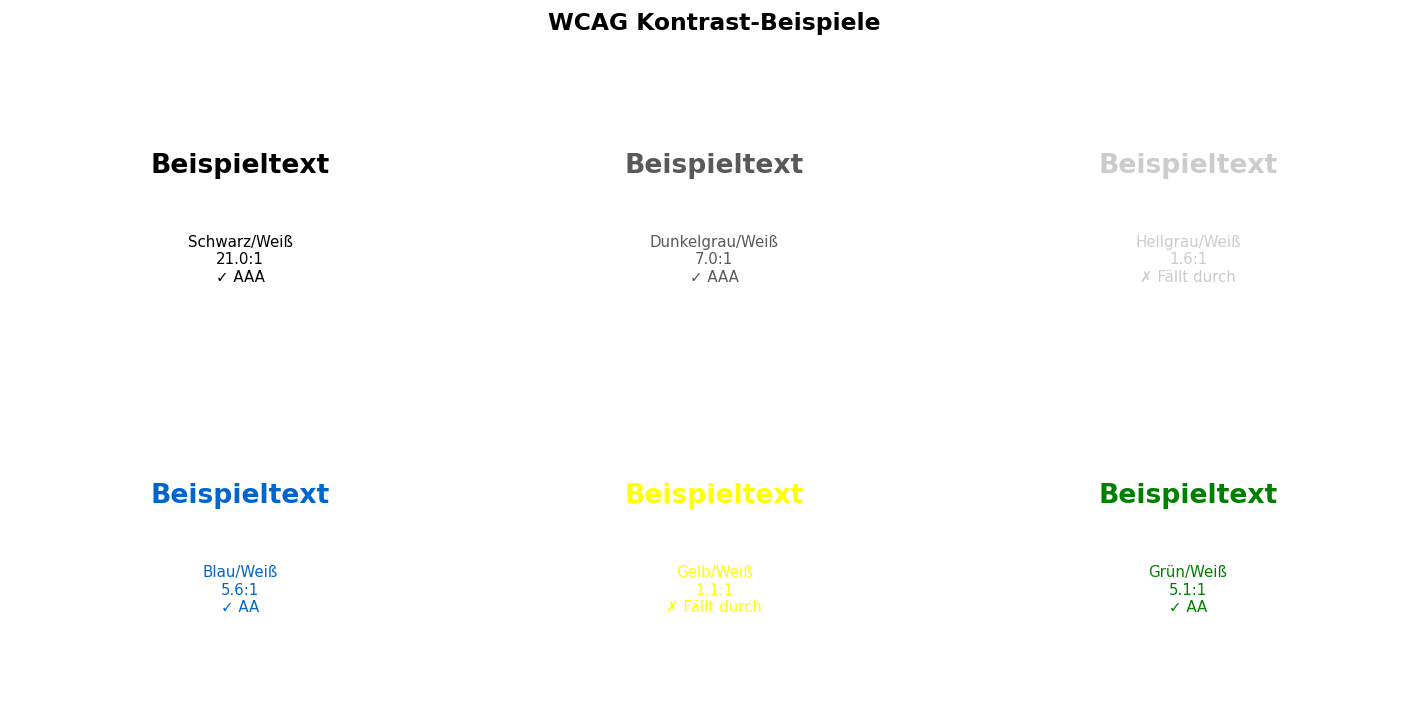

Legende: Grüner Rahmen = besteht AA, Roter Rahmen = fällt durch


In [2]:
# Teste häufige Farbkombinationen
tests = [
    ('Schwarz/Weiß', '#000000', '#FFFFFF'),
    ('Dunkelgrau/Weiß', '#595959', '#FFFFFF'),
    ('Hellgrau/Weiß', '#CCCCCC', '#FFFFFF'),  # Fällt durch
    ('Blau/Weiß', '#0066CC', '#FFFFFF'),
    ('Gelb/Weiß', '#FFFF00', '#FFFFFF'),  # Fällt durch
    ('Grün/Weiß', '#008000', '#FFFFFF'),
]

fig, axes = plt.subplots(2, 3, figsize=(12, 6), dpi=120)
axes = axes.ravel()

for i, (name, fg, bg) in enumerate(tests):
    ax = axes[i]
    ratio = contrast_ratio(fg, bg)
    passes_aa = ratio >= 4.5
    passes_aaa = ratio >= 7.0
    
    ax.add_patch(mpatches.Rectangle((0,0), 1, 1, facecolor=bg, edgecolor='none'))
    ax.text(0.5, 0.65, 'Beispieltext', ha='center', va='center',
            fontsize=16, color=fg, weight='bold')
    
    status = '✓ AAA' if passes_aaa else ('✓ AA' if passes_aa else '✗ Fällt durch')
    ax.text(0.5, 0.35, f'{name}\n{ratio:.1f}:1\n{status}',
            ha='center', va='center', fontsize=9, color=fg)
    
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')
    
    border_color = '#006600' if passes_aa else '#CC0000'
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color(border_color)
        spine.set_linewidth(3)

fig.suptitle('WCAG Kontrast-Beispiele', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Legende: Grüner Rahmen = besteht AA, Roter Rahmen = fällt durch")

## 2. Farbenblindheit

**Häufige Typen:**
- **Protanopie** (1% Männer): Rot-blind
- **Deuteranopie** (1% Männer): Grün-blind
- **Tritanopie** (selten): Blau-blind

**Lösung:** Niemals nur auf Farbe verlassen!

/var/folders/8p/rzwrgzr95qngdjh40ggdxzf80000gn/T/ipykernel_96591/4106533776.py:32: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/andrearachetta/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


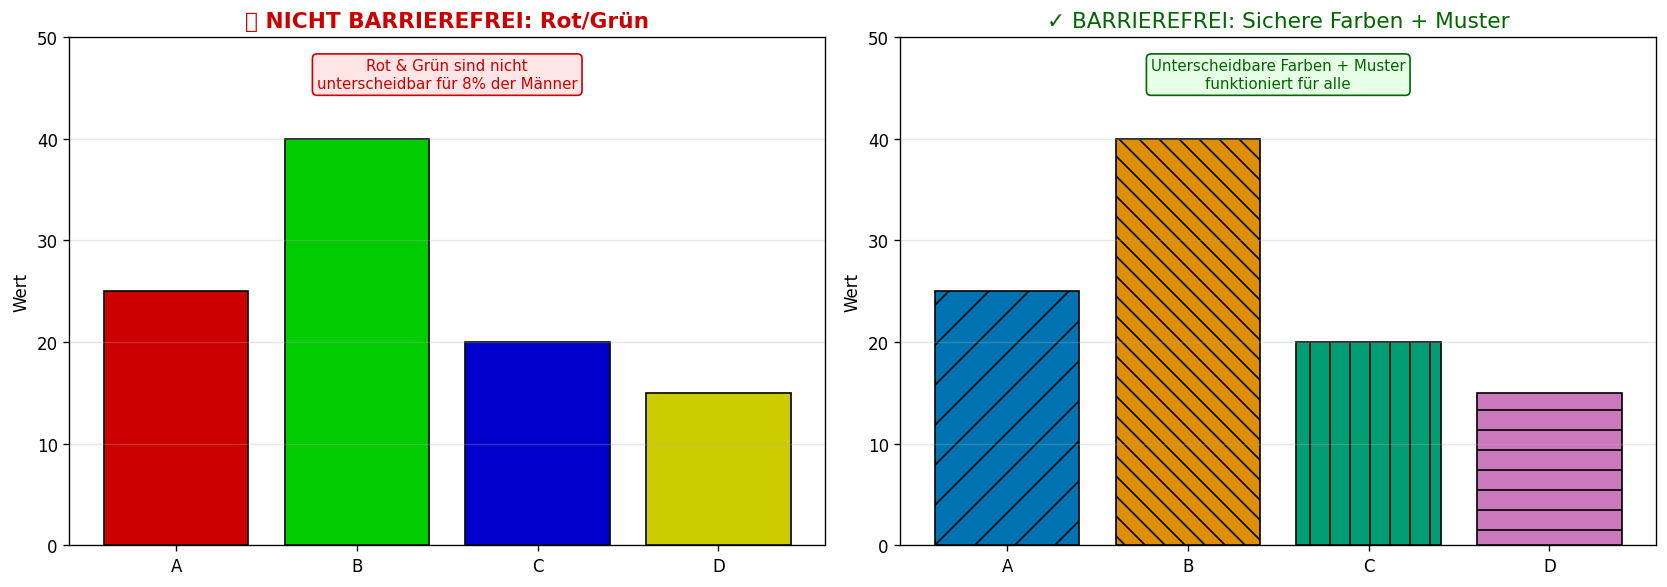

In [3]:
categories = ['A', 'B', 'C', 'D']
values = [25, 40, 20, 15]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), dpi=120)

# SCHLECHT: Rot/Grün
colors_bad = ['#CC0000', '#00CC00', '#0000CC', '#CCCC00']
ax1.bar(categories, values, color=colors_bad, edgecolor='black', linewidth=1)
ax1.set_title('❌ NICHT BARRIEREFREI: Rot/Grün', fontsize=13, fontweight='bold', color='#CC0000')
ax1.set_ylabel('Wert')
ax1.set_ylim(0, 50)
ax1.grid(True, alpha=0.3, axis='y')
ax1.text(0.5, 0.9, 'Rot & Grün sind nicht\nunterscheidbar für 8% der Männer',
         transform=ax1.transAxes, ha='center', fontsize=9, color='#CC0000',
         bbox=dict(boxstyle='round', facecolor='#FFE6E6', edgecolor='#CC0000'))

# GUT: Farbenblind-sichere Palette + Muster
colors_good = ['#0173B2', '#DE8F05', '#029E73', '#CC78BC']
patterns = ['/', '\\\\', '|', '-']
bars = ax2.bar(categories, values, color=colors_good, edgecolor='black', linewidth=1)
for bar, pattern in zip(bars, patterns):
    bar.set_hatch(pattern)

ax2.set_title('✓ BARRIEREFREI: Sichere Farben + Muster', fontsize=13, color='#006600')
ax2.set_ylabel('Wert')
ax2.set_ylim(0, 50)
ax2.grid(True, alpha=0.3, axis='y')
ax2.text(0.5, 0.9, 'Unterscheidbare Farben + Muster\nfunktioniert für alle',
         transform=ax2.transAxes, ha='center', fontsize=9, color='#006600',
         bbox=dict(boxstyle='round', facecolor='#E6FFE6', edgecolor='#006600'))

plt.tight_layout()
plt.show()

## 3. Barrierefreie Farbpaletten

**Empfohlene Paletten:**
- **Okabe-Ito**: Für Farbenblindheit entwickelt
- **Paul Tol**: Hoher Kontrast
- **IBM Design**: Modern, barrierefrei

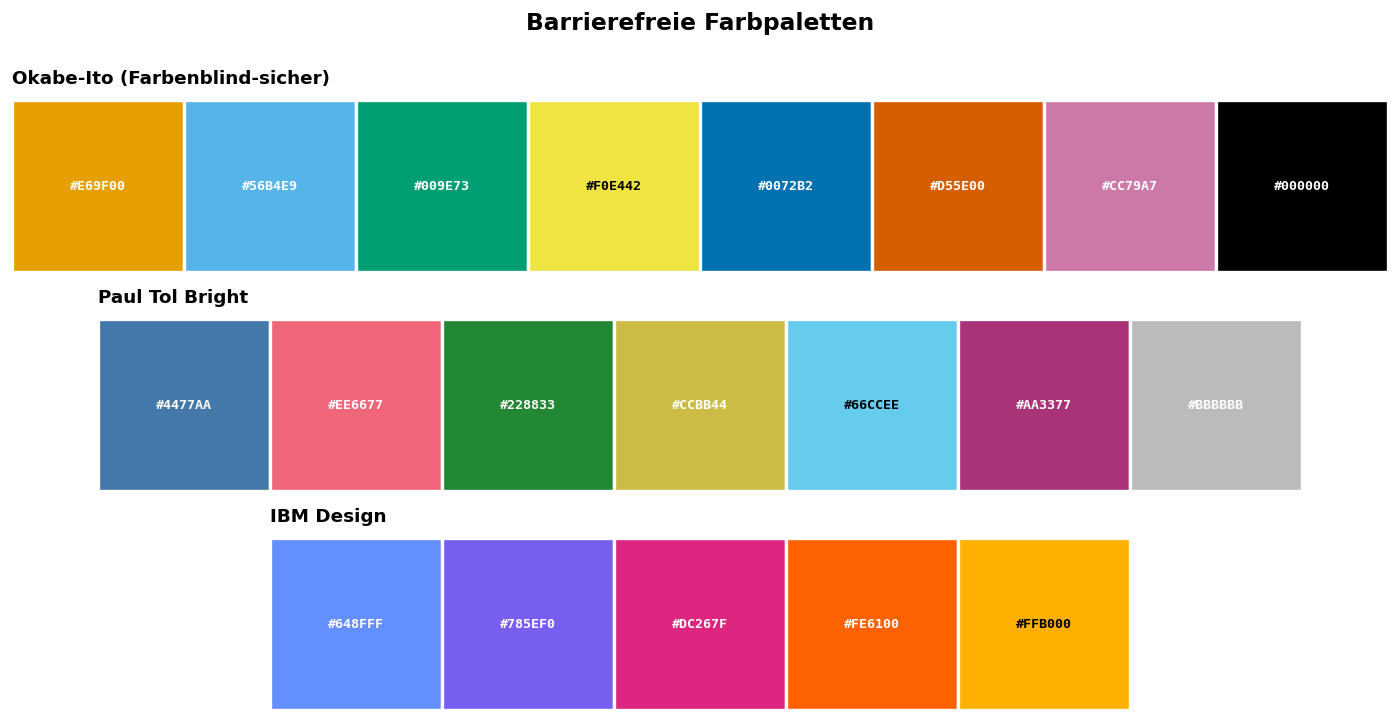

Alle Paletten sind für Farbenblinde unterscheidbar!


In [4]:
palettes = {
    'Okabe-Ito (Farbenblind-sicher)': [
        '#E69F00', '#56B4E9', '#009E73', '#F0E442',
        '#0072B2', '#D55E00', '#CC79A7', '#000000'
    ],
    'Paul Tol Bright': [
        '#4477AA', '#EE6677', '#228833', '#CCBB44',
        '#66CCEE', '#AA3377', '#BBBBBB'
    ],
    'IBM Design': [
        '#648FFF', '#785EF0', '#DC267F', '#FE6100', '#FFB000'
    ],
}

fig, axes = plt.subplots(len(palettes), 1, figsize=(12, 6), dpi=120)

for ax, (name, colors) in zip(axes, palettes.items()):
    for i, color in enumerate(colors):
        ax.add_patch(mpatches.Rectangle((i, 0), 1, 1, facecolor=color, edgecolor='white', linewidth=2))
        text_color = '#FFFFFF' if relative_luminance(to_rgb(color)) < 0.5 else '#000000'
        ax.text(i + 0.5, 0.5, color, ha='center', va='center',
                fontsize=8, color=text_color, weight='bold', family='monospace')
    
    ax.set_xlim(0, len(colors))
    ax.set_ylim(0, 1)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title(name, loc='left', fontsize=11, weight='bold', pad=10)

fig.suptitle('Barrierefreie Farbpaletten', fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

print("Alle Paletten sind für Farbenblinde unterscheidbar!")

## 4. Praktisches Beispiel: Liniendiagramme

**Problem:** Farbe allein reicht nicht

**Lösung:** Farbe + Linienstil + Marker + Beschriftungen

/var/folders/8p/rzwrgzr95qngdjh40ggdxzf80000gn/T/ipykernel_96591/1469844154.py:46: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


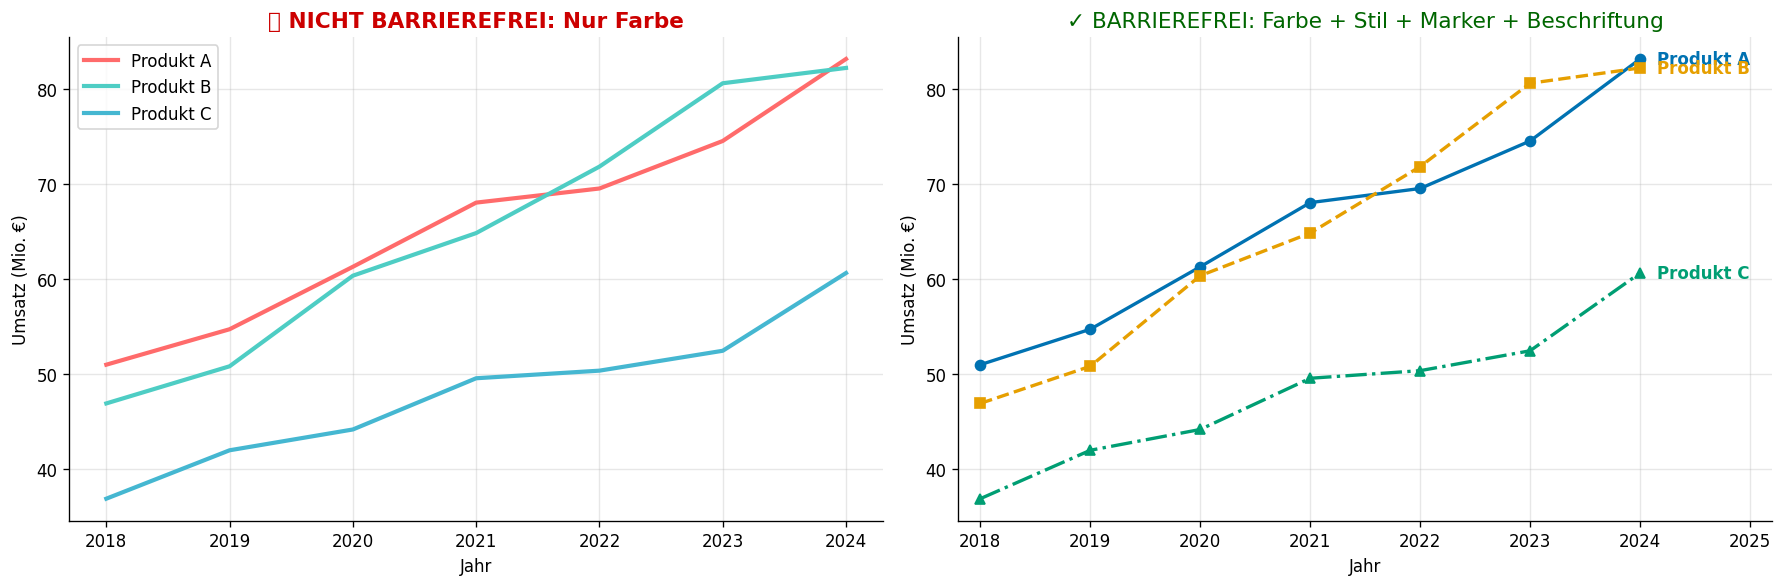

Information über 4 Kanäle: Farbe, Linienstil, Marker-Form, Position


In [5]:
years = np.arange(2018, 2025)
data_a = 50 + 5*np.arange(len(years)) + np.random.normal(0, 2, len(years))
data_b = 45 + 7*np.arange(len(years)) + np.random.normal(0, 2.5, len(years))
data_c = 40 + 3*np.arange(len(years)) + np.random.normal(0, 1.8, len(years))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5), dpi=120)

# SCHLECHT: Nur Farbe
colors_bad = ['#FF6B6B', '#4ECDC4', '#45B7D1']
ax1.plot(years, data_a, color=colors_bad[0], linewidth=2.5, label='Produkt A')
ax1.plot(years, data_b, color=colors_bad[1], linewidth=2.5, label='Produkt B')
ax1.plot(years, data_c, color=colors_bad[2], linewidth=2.5, label='Produkt C')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)
ax1.set_title('❌ NICHT BARRIEREFREI: Nur Farbe', fontsize=13, fontweight='bold', color='#CC0000')
ax1.set_xlabel('Jahr')
ax1.set_ylabel('Umsatz (Mio. €)')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# GUT: Mehrere Kodierungen
colors_good = ['#0072B2', '#E69F00', '#009E73']  # Okabe-Ito
styles = ['-', '--', '-.']
markers = ['o', 's', '^']

ax2.plot(years, data_a, color=colors_good[0], linewidth=2, linestyle=styles[0],
         marker=markers[0], markersize=6, markevery=1)
ax2.plot(years, data_b, color=colors_good[1], linewidth=2, linestyle=styles[1],
         marker=markers[1], markersize=6, markevery=1)
ax2.plot(years, data_c, color=colors_good[2], linewidth=2, linestyle=styles[2],
         marker=markers[2], markersize=6, markevery=1)

# Direkte Beschriftungen
ax2.text(years[-1]+0.15, data_a[-1], 'Produkt A', va='center', fontsize=10, color=colors_good[0], weight='bold')
ax2.text(years[-1]+0.15, data_b[-1], 'Produkt B', va='center', fontsize=10, color=colors_good[1], weight='bold')
ax2.text(years[-1]+0.15, data_c[-1], 'Produkt C', va='center', fontsize=10, color=colors_good[2], weight='bold')

ax2.set_xlim(years[0]-0.2, years[-1]+1.2)
ax2.grid(True, alpha=0.3)
ax2.set_title('✓ BARRIEREFREI: Farbe + Stil + Marker + Beschriftung', fontsize=13, color='#006600')
ax2.set_xlabel('Jahr')
ax2.set_ylabel('Umsatz (Mio. €)')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

print("Information über 4 Kanäle: Farbe, Linienstil, Marker-Form, Position")

## 5. Farben testen

**Online-Tools:**
- WebAIM Contrast Checker: https://webaim.org/resources/contrastchecker/
- Coblis Farbenblind-Simulator: https://www.color-blindness.com/coblis-color-blindness-simulator/
- ColorBrewer: https://colorbrewer2.org/


Teste: #000000 auf #FFFFFF
Kontrastverhältnis: 21.00:1
WCAG AA (4.5:1):  ✓ BESTANDEN
WCAG AAA (7:1):   ✓ BESTANDEN


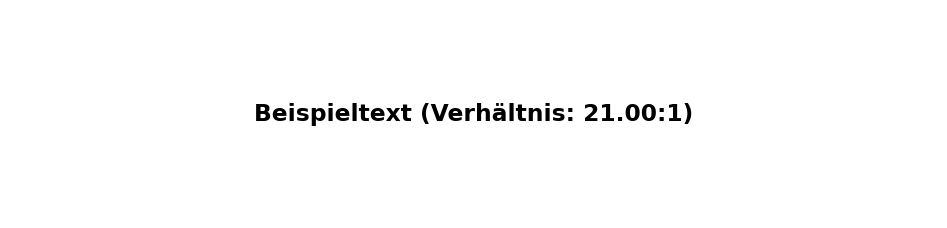


Teste: #767676 auf #FFFFFF
Kontrastverhältnis: 4.54:1
WCAG AA (4.5:1):  ✓ BESTANDEN
WCAG AAA (7:1):   ✗ DURCHGEFALLEN


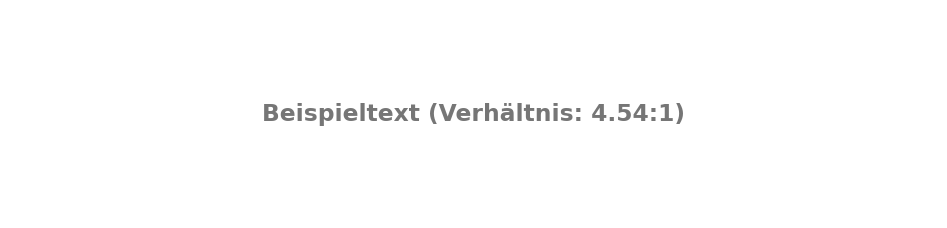

In [6]:
def test_color_pair(fg, bg):
    """Teste eine Farbkombination auf WCAG-Konformität"""
    ratio = contrast_ratio(fg, bg)
    aa_pass = ratio >= 4.5
    aaa_pass = ratio >= 7.0
    
    print(f"\nTeste: {fg} auf {bg}")
    print(f"Kontrastverhältnis: {ratio:.2f}:1")
    print(f"WCAG AA (4.5:1):  {'✓ BESTANDEN' if aa_pass else '✗ DURCHGEFALLEN'}")
    print(f"WCAG AAA (7:1):   {'✓ BESTANDEN' if aaa_pass else '✗ DURCHGEFALLEN'}")
    
    fig, ax = plt.subplots(1, 1, figsize=(8, 2), dpi=120)
    ax.add_patch(mpatches.Rectangle((0,0), 1, 1, facecolor=bg))
    ax.text(0.5, 0.5, f'Beispieltext (Verhältnis: {ratio:.2f}:1)',
            ha='center', va='center', fontsize=14, color=fg, weight='bold')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')
    
    border_color = '#006600' if aa_pass else '#CC0000'
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color(border_color)
        spine.set_linewidth(4)
    
    plt.tight_layout()
    plt.show()

# Teste Beispiele
test_color_pair('#000000', '#FFFFFF')  # Schwarz auf Weiß
test_color_pair('#767676', '#FFFFFF')  # Grau auf Weiß (Grenzfall)

## Best Practices Zusammenfassung

### ✓ TUN:
1. Hohen Kontrast verwenden (4.5:1 minimum)
2. Farbenblind-sichere Paletten wählen
3. Redundante Kodierung hinzufügen (Muster, Formen, Beschriftungen)
4. Designs testen
5. Blau/Orange statt Rot/Grün verwenden
6. Helligkeit variieren, nicht nur Farbton
7. Palette begrenzen
8. Direkte Beschriftungen verwenden

### ✗ NICHT TUN:
1. Nur auf Farbe verlassen
2. Rot/Grün-Kombinationen verwenden
3. Niedrigen Kontrast verwenden
4. Zu viele Farben verwenden
5. Vergessen zu testen
6. Regenbogen-Paletten verwenden
7. WCAG-Standards ignorieren
8. Annehmen, dass alle wie Sie sehen

### Schnellreferenz:

| Situation | Minimum | Empfohlen |
|-----------|---------|----------|
| Fließtext | 4.5:1 | 7:1 |
| Großer Text (18pt+) | 3:1 | 4.5:1 |
| Grafiken/UI | 3:1 | Höher |

---

## Übungsaufgaben

### Aufgabe 1: Kontrast testen
Teste diese Farbkombinationen:
- `#0066CC` auf `#FFFFFF`
- `#999999` auf `#FFFFFF`
- `#FFFFFF` auf `#0066CC`

Welche bestehen AA? Welche AAA?

### Aufgabe 2: Palette verbessern
Gegeben: `['#FF0000', '#00FF00', '#0000FF']`

Ersetze diese durch eine farbenblind-sichere Palette.

### Aufgabe 3: Diagramm verbessern
Erstelle ein Liniendiagramm mit 3 Linien, das:
- Farbenblind-sichere Farben verwendet
- Unterschiedliche Linienstile hat
- Marker verwendet
- Direkte Beschriftungen hat

---

*Erstellt für den HsH Data Visualization Kurs - April 2026*